In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

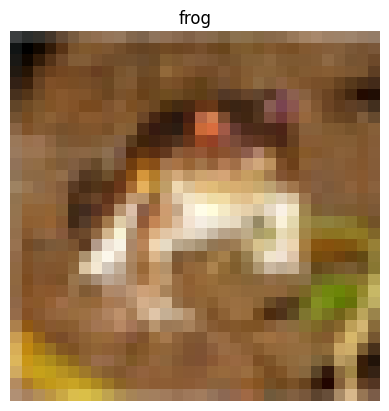

In [3]:
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.4483 - loss: 1.5109 - val_accuracy: 0.5372 - val_loss: 1.2741
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.5942 - loss: 1.1436 - val_accuracy: 0.6232 - val_loss: 1.0570
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.6553 - loss: 0.9801 - val_accuracy: 0.6654 - val_loss: 0.9658
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.6913 - loss: 0.8855 - val_accuracy: 0.6634 - val_loss: 0.9688
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.7177 - loss: 0.8108 - val_accuracy: 0.6963 - val_loss: 0.8963
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7393 - loss: 0.7487 - val_accuracy: 0.7010 - val_loss: 0.8768
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7561 - loss: 0.6992 - val_accuracy: 0.7066 - val_loss: 0.8720
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7716 -

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7091 - loss: 0.8847
Test Accuracy: 0.7091000080108643
Test Loss: 0.8846558332443237


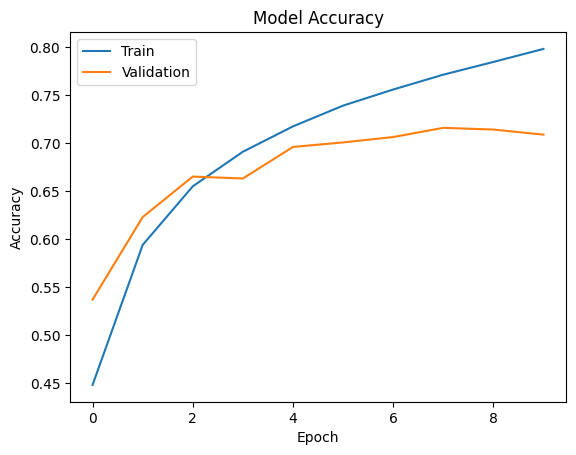

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [11]:
pred = model.predict(x_test[:1])

print("Predicted:", class_names[np.argmax(pred)])
print("Actual:", class_names[y_test[0][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted: cat
Actual: cat
